# Mesh Tutorial 8: I/O - Interoperability and Serialization

Getting meshes **in and out** of PhysicsNeMo-Mesh: importing from PyVista/VTK, importing raw polygon soups (which means *triangulating* them), exporting back to PyVista, and saving/loading in the native on-disk format.

## What You'll Learn

1. Why importing a surface usually means *triangulating* it: a `Mesh` stores only simplices
2. Importing from PyVista with `from_pyvista` (it triangulates non-triangle cells for you)
3. Importing a raw polygon soup with `Adjacency` + `triangulate` / `Mesh.from_polygons`
4. Why non-convex polygons need ear clipping, and how to get it for free
5. Exporting back to PyVista with `to_pyvista`
6. Saving and loading meshes in PhysicsNeMo's native format

## The one idea behind mesh I/O: simplices

A PhysicsNeMo `Mesh` stores connectivity as a single dense `cells` tensor of shape `(n_cells, n_manifold_dims + 1)`, i.e. **simplices** (triangles for surfaces, tetrahedra for volumes). That uniformity is what makes every operation vectorizable on the GPU.

Real meshes are messier: a CFD surface from VTK or OpenFOAM is a *polygon soup* with mixed cell types (triangles, quads, pentagons, ...). So "import a surface mesh" almost always means **triangulate it first**. This tutorial walks through that, from the one-liner to full control.

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pyvista as pv
import torch

from physicsnemo.mesh import DomainMesh, Mesh
from physicsnemo.mesh.io import from_pyvista, to_pyvista
from physicsnemo.mesh.neighbors import Adjacency
from physicsnemo.mesh.tessellation import triangulate


def print_tree(root: Path, prefix: str = "", *, show_cache: bool = True) -> None:
    """Print a ``tree``-style listing of ``root``, with each file's size in bytes.

    A dependency-free stand-in for the ``tree`` shell command so the notebook
    runs anywhere. Pass ``show_cache=False`` to hide the internal ``_cache``
    folders when they would only add noise.
    """
    entries = sorted(
        (p for p in root.iterdir() if show_cache or p.name != "_cache"),
        key=lambda p: (p.is_file(), p.name),
    )
    for i, entry in enumerate(entries):
        is_last = i == len(entries) - 1
        annotation = f"  [{entry.stat().st_size:,} B]" if entry.is_file() else "/"
        print(f"{prefix}{'`-- ' if is_last else '|-- '}{entry.name}{annotation}")
        if entry.is_dir():
            print_tree(
                entry, prefix + ("    " if is_last else "|   "), show_cache=show_cache
            )

/home/psharpe/gh/physicsnemo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Importing from PyVista

The easiest on-ramp is `from_pyvista`, which converts any PyVista `PolyData` or `UnstructuredGrid` into a `Mesh`, **triangulating non-triangular cells automatically** (via VTK) so the result fits the simplex-only model.

Two options are worth knowing:

* `manifold_dim` (`"auto"`, `0`, `1`, `2`, `3`): the target topology. `"auto"` infers it; force `2` for a surface or `3` for a tetrahedral volume.
* `point_source` (`"vertices"` or `"cell_centroids"`): whether each `Mesh` point is an original vertex, or the centroid of a *cell*. The centroid mode gives a point cloud, or the mesh's **dual graph** when `manifold_dim=1` (covered just below).

In [2]:
# A PyVista plane made of QUADS (not triangles).
plane = pv.Plane(i_resolution=3, j_resolution=2)
print(f"PyVista input : {plane.n_cells} cells, all triangles? {plane.is_all_triangles}")

# from_pyvista triangulates automatically, so the cell count grows.
mesh = from_pyvista(plane, manifold_dim="auto")
print(
    f"PhysicsNeMo   : {mesh.n_cells} triangular cells, cells shape {tuple(mesh.cells.shape)}"
)
print(mesh)

PyVista input : 6 cells, all triangles? False
PhysicsNeMo   : 12 triangular cells, cells shape (12, 3)
Mesh[n_manifold_dims=2, n_spatial_dims=3](n_points=12, n_cells=12)
    point_data: {Normals: (3,), TextureCoordinates: (2,)}


### `vertices` vs `cell_centroids`: the mesh, or its dual graph

`point_source` decides what a `Mesh` *point* represents:

* **`"vertices"`** keeps the original vertices, so you get the mesh you expect (e.g. with `manifold_dim=3`, the tetrahedralized **volume**, `Mesh[3, 3]`).
* **`"cell_centroids"`** places one point at each *cell's* centroid (and moves `cell_data` onto those points). With `manifold_dim=0` that is a point cloud (`Mesh[0, 3]`); with `manifold_dim=1` it is the mesh's **dual graph** (`Mesh[1, 3]`): the nodes are the cell centroids, and the edges (the new `cells`) connect cells that share a face in the original mesh. (`"auto"` resolves to `0` here.)

Because those edges come from face adjacency, the dual graph needs a **volume** mesh (surface polygons have edges, not faces). Below we load a small block of hexahedra both ways: on the left the tetrahedralized volume, on the right its cell-adjacency graph, which is exactly the "which cells are neighbors" connectivity a graph network consumes.

vertices       -> Mesh[3, 3]: 24 points, 36 tetrahedra
cell_centroids -> Mesh[1, 3]: 6 centroid nodes, 7 neighbor edges


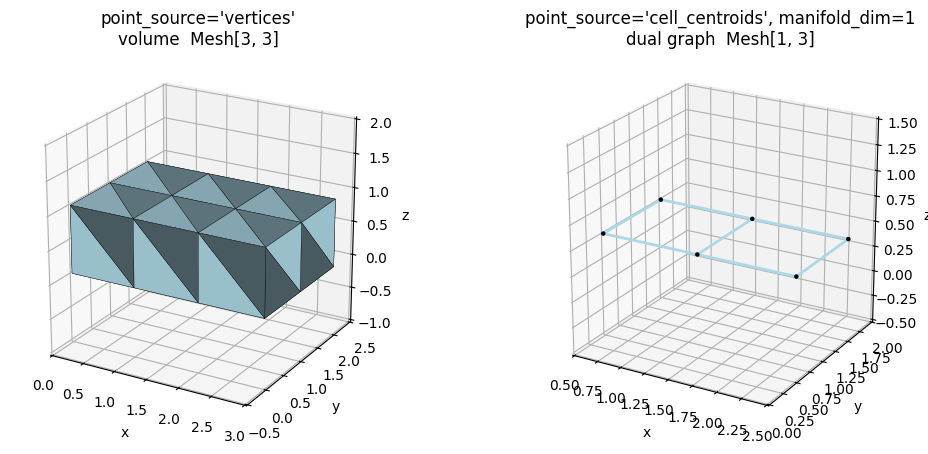

In [3]:
# Dual graphs come from cell ADJACENCY, so they need a volume mesh whose cells
# have faces. Build a small 3x2x1 block of hexahedra.
volume = pv.ImageData(dimensions=(4, 3, 2)).cast_to_unstructured_grid()

solid = from_pyvista(volume, point_source="vertices", manifold_dim=3)
dual = from_pyvista(volume, point_source="cell_centroids", manifold_dim=1)
print(
    f"vertices       -> Mesh[{solid.n_manifold_dims}, {solid.n_spatial_dims}]: "
    f"{solid.n_points} points, {solid.n_cells} tetrahedra"
)
print(
    f"cell_centroids -> Mesh[{dual.n_manifold_dims}, {dual.n_spatial_dims}]: "
    f"{dual.n_points} centroid nodes, {dual.n_cells} neighbor edges"
)

# Draw both in 3D: the volume's boundary surface, and the cell-adjacency graph.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), subplot_kw={"projection": "3d"})
solid.draw(backend="matplotlib", ax=axes[0], show=False)
axes[0].set_title("point_source='vertices'\nvolume  Mesh[3, 3]")
dual.draw(backend="matplotlib", ax=axes[1], show=False)
axes[1].set_title(
    "point_source='cell_centroids', manifold_dim=1\ndual graph  Mesh[1, 3]"
)
for ax in axes:
    ax.view_init(elev=22, azim=-60)
fig.tight_layout()
plt.show()

## Section 2: Importing a raw polygon soup

When you have raw arrays (for example straight from a file reader) instead of a PyVista object, describe the polygons as an `Adjacency`, the library's compressed-row (CSR) ragged container, and call `triangulate`.

A polygon `Adjacency` is exactly what `physicsnemo.mesh.neighbors.get_cell_to_points_adjacency` returns: `indices` is the concatenated per-polygon vertex rings, and `offsets` are the row pointers (cumulative vertex counts, starting at 0). So a triangle followed by a quad has `offsets=[0, 3, 7]`.

In [4]:
# A tiny soup: one triangle (vertices 0,1,2) and one quad (3,4,5,6), in 2D.
points = torch.tensor(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [0.0, 1.0],  # triangle
        [2.0, 0.0],
        [3.0, 0.0],
        [3.0, 1.0],
        [2.0, 1.0],  # quad
    ]
)
polygons = Adjacency(
    offsets=torch.tensor([0, 3, 7]),  # triangle ends at index 3, quad at 7
    indices=torch.tensor([0, 1, 2, 3, 4, 5, 6]),
)

cells, parent_index = triangulate(points, polygons)
print("triangles:\n", cells)
print("source polygon of each triangle:", parent_index.tolist())

triangles:
 tensor([[0, 1, 2],
        [3, 4, 5],
        [3, 5, 6]])
source polygon of each triangle: [0, 1, 1]


### Carrying per-polygon data across the triangulation

`parent_index` maps every output triangle back to its source polygon, so any per-polygon field broadcasts with a single index: `cell_data[parent_index]`. `Mesh.from_polygons` does exactly this and hands you a ready-to-use `Mesh`.

In [5]:
# One pressure value per polygon; from_polygons broadcasts it onto the triangles.
pressure = torch.tensor([10.0, 20.0])  # triangle, quad
mesh = Mesh.from_polygons(points, polygons, cell_data={"pressure": pressure})
print(mesh)
print("per-triangle pressure:", mesh.cell_data["pressure"].tolist())  # [10, 20, 20]

Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=7, n_cells=3)
    cell_data: {pressure: ()}
per-triangle pressure: [10.0, 20.0, 20.0]


## Section 3: Why non-convex polygons need ear clipping

A tempting way to triangulate a polygon is a *fan* from its first vertex: `(v0,v1,v2), (v0,v2,v3), ...`. That is exactly right for **convex** polygons, and `triangulate` uses it as a fast, fully vectorized path.

For a **non-convex** polygon a fan emits triangles that overlap and spill outside the polygon, so their areas no longer sum to the true area (the figure below makes this concrete on a 'dart' quadrilateral). That silently corrupts any area- or normal-weighted quantity (surface area, viscous force, ...). By default `triangulate` detects non-convex polygons and **ear-clips** them instead.

Pass `assume_convex=True` only when every polygon is convex (most CFD surface cells are): it skips the check, and the call is then graph-break-free under `torch.compile(fullgraph=True)`. See Tutorial 6 for the performance angle.

In [6]:
# A non-convex "dart" quadrilateral (vertex 3 is reflex). Its true area is 6.
dart_points = torch.tensor([[0.0, 0.0], [4.0, 2.0], [0.0, 4.0], [1.0, 2.0]])
dart = Adjacency(offsets=torch.tensor([0, 4]), indices=torch.tensor([0, 1, 2, 3]))


def total_area(cells: torch.Tensor) -> float:
    return float(Mesh(points=dart_points, cells=cells).cell_areas.sum())


fan_cells, _ = triangulate(dart_points, dart, assume_convex=True)  # naive fan
good_cells, _ = triangulate(dart_points, dart)  # default: ear clip

print(
    f"naive fan : total area = {total_area(fan_cells):.1f}  (wrong, triangles overlap)"
)
print(f"ear clip  : total area = {total_area(good_cells):.1f}  (correct)")

naive fan : total area = 10.0  (wrong, triangles overlap)
ear clip  : total area = 6.0  (correct)


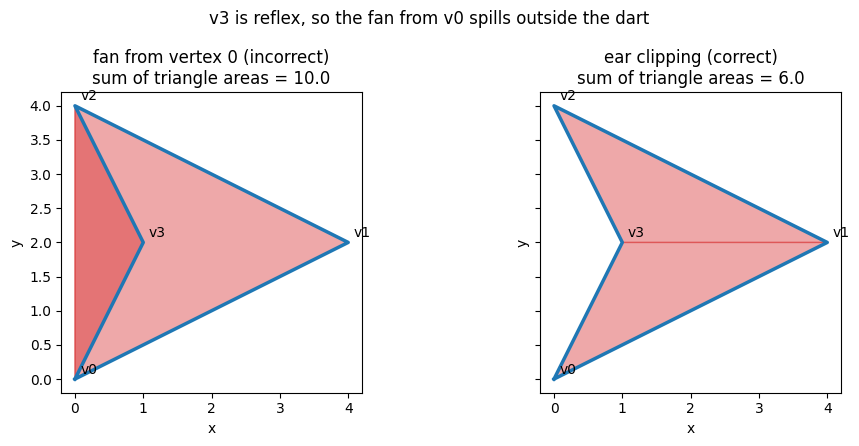

In [7]:
# Show *why* the fan is wrong: fill each triangle translucently and draw the
# true dart outline on top. The fan's triangles spill past the outline and
# overlap (darker red); the ear-clip tiles the dart exactly.
dp = dart_points.numpy()
outline = [*range(len(dp)), 0]  # closed vertex loop

fig, (ax_fan, ax_ear) = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax, cells, title in [
    (ax_fan, fan_cells, "fan from vertex 0 (incorrect)"),
    (ax_ear, good_cells, "ear clipping (correct)"),
]:
    for triangle in cells.numpy():
        ax.fill(dp[triangle, 0], dp[triangle, 1], color="C3", alpha=0.4)
    ax.plot(dp[outline, 0], dp[outline, 1], color="C0", linewidth=2.5)
    for vertex, (x, y) in enumerate(dp):
        ax.annotate(f"v{vertex}", (x, y), textcoords="offset points", xytext=(4, 4))
    ax.set_title(f"{title}\nsum of triangle areas = {total_area(cells):.1f}")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("v3 is reflex, so the fan from v0 spills outside the dart")
fig.tight_layout()
plt.show()

## Section 4: Exporting back to PyVista

`to_pyvista` is the inverse of `from_pyvista`: it hands your `Mesh` back to the PyVista/VTK ecosystem for visualization, file export, or interop with other tools. Below we also draw the imported soup, colored by the pressure we broadcast onto its triangles.

PolyData: 3 cells, 7 points


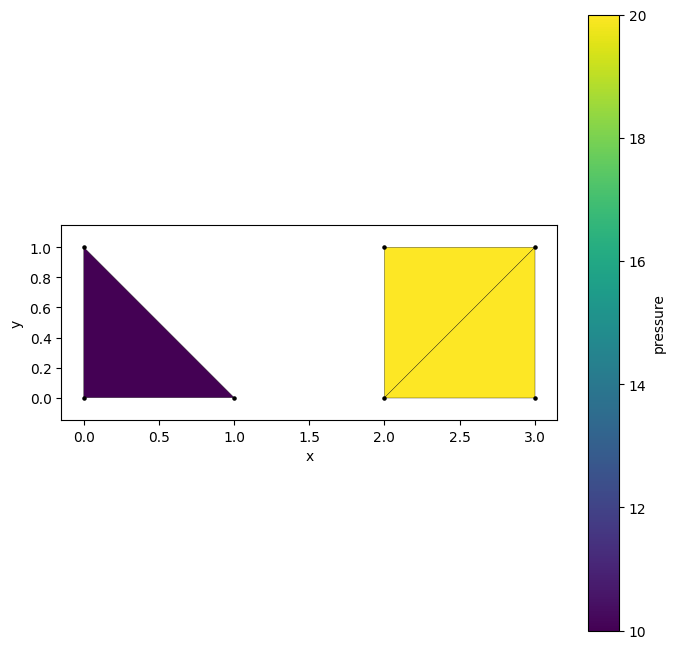

In [8]:
pv_out = to_pyvista(mesh)
print(f"{type(pv_out).__name__}: {pv_out.n_cells} cells, {pv_out.n_points} points")

# Draw with the matplotlib backend (renders without a display server).
_ = mesh.draw(backend="matplotlib", cell_scalars="pressure")

## Section 5: Saving and loading meshes

`Mesh.save(path)` and `Mesh.load(path)` are the recommended way to persist a mesh. Unlike `torch.save`/pickle, the native format is a *directory* of memory-mapped tensors: safe (no arbitrary code execution on load), fast (parallel I/O), and lazily/partially loadable. By convention these directories use the `.pmsh` extension (`.pdmsh` for a `DomainMesh`), recognized by the dataset readers in `physicsnemo.datapipes`.

Let's attach data to all three containers, save, and look at exactly what lands on disk.

In [9]:
# Attach data to all three containers so the on-disk layout is illustrative.
mesh.point_data["temperature"] = torch.linspace(300.0, 320.0, mesh.n_points)
mesh.global_data["mach"] = torch.tensor(0.3)
mesh.global_data["freestream"] = torch.tensor([30.0, 0.0])  # 2D velocity vector

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "surface.pmsh"
    mesh.save(str(path))

    # The "file" is really a directory tree of memory-mapped tensors.
    print(f"{path.name}/")
    print_tree(path)

    reloaded = Mesh.load(str(path))
    matches = (
        torch.equal(mesh.points, reloaded.points)
        and torch.equal(mesh.cells, reloaded.cells)
        and torch.equal(
            mesh.point_data["temperature"], reloaded.point_data["temperature"]
        )
        and torch.equal(mesh.cell_data["pressure"], reloaded.cell_data["pressure"])
        and torch.equal(mesh.global_data["mach"], reloaded.global_data["mach"])
    )
    print(f"\nreloaded: {reloaded}")
    print("all fields round-trip exactly:", matches)

surface.pmsh/
|-- _tensordict/
|   |-- _cache/
|   |   |-- cell/
|   |   |   `-- meta.json  [79 B]
|   |   |-- point/
|   |   |   `-- meta.json  [79 B]
|   |   |-- topology/
|   |   |   `-- meta.json  [78 B]
|   |   `-- meta.json  [179 B]
|   |-- cell_data/
|   |   |-- meta.json  [170 B]
|   |   `-- pressure.memmap  [12 B]
|   |-- global_data/
|   |   |-- freestream.memmap  [8 B]
|   |   |-- mach.memmap  [4 B]
|   |   `-- meta.json  [257 B]
|   |-- point_data/
|   |   |-- meta.json  [173 B]
|   |   `-- temperature.memmap  [28 B]
|   |-- cells.memmap  [72 B]
|   |-- meta.json  [407 B]
|   `-- points.memmap  [56 B]
`-- meta.json  [49 B]

reloaded: Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=7, n_cells=3, device=cpu)
    point_data : {temperature: ()}
    cell_data  : {pressure: ()}
    global_data: {freestream: (2,), mach: ()}
all fields round-trip exactly: True


### Anatomy of the on-disk format

The `.pmsh` "file" is a **directory**, and the tree above mirrors the `Mesh` object one-to-one:

* Each leaf tensor is a raw, memory-mapped `*.memmap` file whose size is exactly `numel x itemsize` (e.g. `points.memmap` is `7 x 2 x 4 = 56` bytes for `float32`). On load, these are `mmap`-ed straight from disk - no unpickling, no copy.
* Every level carries a `meta.json` recording shapes, dtypes, and the tensorclass type, which is how `Mesh.load` reconstructs the *exact* class rather than a bare dict.
* The `point_data/`, `cell_data/`, and `global_data/` subfolders hold your attached fields; they exist even when empty.
* `_tensordict/` and `_cache/` are `tensorclass` plumbing - `_cache` holds lazily-computed geometric properties (cell areas, normals, ...) and is empty here because none have been requested yet.

Two practical consequences fall out of the memmap design: you can load meshes larger than RAM and read their tensors in parallel, and zero-element tensors are *not* written (a bare point cloud's placeholder `cells` is simply restored on load). This is what makes the format safer and faster than `torch.save`/pickle.

### `DomainMesh`: the same format, nested

A `DomainMesh` bundles an interior mesh, named boundary meshes, and domain-level `global_data` (Reynolds number, angle of attack, ...). It serializes with the identical scheme, just nested one level deeper: `interior/` and each `boundaries/<name>/` is itself a full mesh tree like the one above. The convention is the `.pdmsh` extension.

In [10]:
# A minimal domain: a tetrahedral interior, two named boundary patches, and
# domain-level scalars. The geometry is tiny; we only care about the layout.
interior = Mesh(
    points=torch.tensor(
        [[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]
    ),
    cells=torch.tensor([[0, 1, 2, 3]]),
    point_data={"wall_distance": torch.tensor([0.0, 1.0, 1.0, 1.0])},
)
wall = Mesh(
    points=torch.tensor([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]),
    cells=torch.tensor([[0, 1, 2]]),
    cell_data={"pressure": torch.tensor([101.3])},
)
inlet = Mesh(
    points=torch.tensor([[2.0, 0.0, 0.0], [3.0, 0.0, 0.0], [2.0, 1.0, 0.0]]),
    cells=torch.tensor([[0, 1, 2]]),
)
domain = DomainMesh(
    interior=interior,
    boundaries={"no_slip": wall, "inlet": inlet},
    global_data={
        "Re": torch.tensor(1.0e6),
        "AoA": torch.tensor(5.0),
        "Mach": torch.tensor(0.3),
    },
)

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "domain.pdmsh"
    domain.save(str(path))

    # interior/, each boundaries/<name>/, and global_data/ nest a full mesh tree.
    # (Internal _cache/ folders hidden to keep the structure readable.)
    print(f"{path.name}/")
    print_tree(path, show_cache=False)

    reloaded = DomainMesh.load(str(path))
    print("\nreloaded boundaries:", reloaded.boundary_names)
    print(
        "global_data + boundary field round-trip:",
        torch.equal(domain.global_data["Re"], reloaded.global_data["Re"])
        and torch.equal(
            domain.boundaries["no_slip"].cell_data["pressure"],
            reloaded.boundaries["no_slip"].cell_data["pressure"],
        ),
    )

domain.pdmsh/
|-- _tensordict/
|   |-- boundaries/
|   |   |-- inlet/
|   |   |   |-- _tensordict/
|   |   |   |   |-- cell_data/
|   |   |   |   |   `-- meta.json  [79 B]
|   |   |   |   |-- global_data/
|   |   |   |   |   `-- meta.json  [78 B]
|   |   |   |   |-- point_data/
|   |   |   |   |   `-- meta.json  [79 B]
|   |   |   |   |-- cells.memmap  [24 B]
|   |   |   |   |-- meta.json  [407 B]
|   |   |   |   `-- points.memmap  [36 B]
|   |   |   `-- meta.json  [49 B]
|   |   |-- no_slip/
|   |   |   |-- _tensordict/
|   |   |   |   |-- cell_data/
|   |   |   |   |   |-- meta.json  [170 B]
|   |   |   |   |   `-- pressure.memmap  [4 B]
|   |   |   |   |-- global_data/
|   |   |   |   |   `-- meta.json  [78 B]
|   |   |   |   |-- point_data/
|   |   |   |   |   `-- meta.json  [79 B]
|   |   |   |   |-- cells.memmap  [24 B]
|   |   |   |   |-- meta.json  [407 B]
|   |   |   |   `-- points.memmap  [36 B]
|   |   |   `-- meta.json  [49 B]
|   |   `-- meta.json  [134 B]
|   |-- global_d

## Recap

* **Import** with `from_pyvista` (it auto-triangulates), or from raw arrays with an `Adjacency` plus `triangulate` / `Mesh.from_polygons`.
* Triangulation is the bridge from a polygon soup to the simplex-only `Mesh`; `parent_index` carries per-polygon data across it.
* Non-convex polygons are ear-clipped by default so areas and forces stay correct; `assume_convex=True` is the fast, compile-friendly path for convex cells.
* **Export** with `to_pyvista`; **persist** with `Mesh.save` / `Mesh.load` (or `DomainMesh.save` / `.load`) - a folder of memory-mapped tensors using the `.pmsh` / `.pdmsh` convention.

### Where to next

* **Tutorial 1**: the `Mesh` data model and `from_pyvista` basics.
* **Tutorial 2**: mesh operations (subdivision, slicing, boundary extraction).
* **Tutorial 6**: performance of these operations in ML pipelines, including `torch.compile`.